In [1]:
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

print("库导入成功")

库导入成功


In [2]:
# 拉取沪深300成分股列表
hs300 = ak.index_stock_cons_weight_csindex(symbol="000300")
print(hs300.shape)
print(hs300.head())

(300, 10)
           日期    指数代码   指数名称   指数英文名称   成分券代码  成分券名称  \
0  2026-02-27  000300  沪深300  CSI 300  000001   平安银行   
1  2026-02-27  000300  沪深300  CSI 300  000002    万科A   
2  2026-02-27  000300  沪深300  CSI 300  000063   中兴通讯   
3  2026-02-27  000300  沪深300  CSI 300  000100  TCL科技   
4  2026-02-27  000300  沪深300  CSI 300  000157   中联重科   

                                             成分券英文名称      交易所  \
0                             Ping An Bank Co., Ltd.  深圳证券交易所   
1                                 China Vanke Co Ltd  深圳证券交易所   
2                                    ZTE Corporation  深圳证券交易所   
3                   TCL Technology Group Corporation  深圳证券交易所   
4  Zoomlion Heavy Industry Science & Technology C...  深圳证券交易所   

                   交易所英文名称     权重  
0  Shenzhen Stock Exchange  0.411  
1  Shenzhen Stock Exchange  0.128  
2  Shenzhen Stock Exchange  0.484  
3  Shenzhen Stock Exchange  0.402  
4  Shenzhen Stock Exchange  0.193  


In [3]:
# 提取股票代码
stock_list = hs300["成分券代码"].tolist()
print(f"共{len(stock_list)}只股票")

# 拉取每只股票最近2年的收盘价
close_dict = {}

for i, code in enumerate(stock_list):
    try:
        df = ak.stock_zh_a_hist(symbol=code, adjust="qfq", 
                                start_date="2023-01-01")
        close_dict[code] = df.set_index("日期")["收盘"]
        if i % 50 == 0:
            print(f"进度：{i}/300")
    except:
        print(f"获取失败：{code}")
        continue

# 合并成一张大表，行是日期，列是股票代码
close_df = pd.DataFrame(close_dict)
close_df.index = pd.to_datetime(close_df.index)

print(f"\n完成，数据维度：{close_df.shape}")
print(close_df.iloc[:3, :5])

共300只股票
进度：0/300
进度：50/300
进度：100/300
进度：150/300
进度：200/300
获取失败：601169
进度：250/300

完成，数据维度：(8619, 299)
            000001  000002  000063  000100  000157
日期                                                
1991-01-29     NaN   -8.83     NaN     NaN     NaN
1991-01-30     NaN   -8.83     NaN     NaN     NaN
1991-02-02     NaN   -8.83     NaN     NaN     NaN


In [4]:
# 只保留2023年之后的数据
close_df = close_df[close_df.index >= "2023-01-01"]

# 删除缺失值超过10%的股票
threshold = len(close_df) * 0.1
close_df = close_df.dropna(axis=1, thresh=len(close_df)-threshold)

print(f"过滤后数据维度：{close_df.shape}")
print(f"时间范围：{close_df.index.min()} 到 {close_df.index.max()}")

过滤后数据维度：(781, 295)
时间范围：2023-01-03 00:00:00 到 2026-03-27 00:00:00


In [5]:
# 对所有股票同时计算20日动量因子
momentum_all = close_df / close_df.shift(20) - 1

print(f"动量因子维度：{momentum_all.shape}")
print(momentum_all.iloc[20:23, :5])

动量因子维度：(781, 295)
              000001    000002    000063    000100    000157
日期                                                          
2023-02-07  0.036913 -0.038177  0.051176  0.099698  0.062212
2023-02-08 -0.022454 -0.085372  0.012530  0.068249  0.045558
2023-02-09 -0.027712 -0.089008  0.056184  0.095238  0.063492


In [6]:
# 未来10天涨幅
future_return_all = close_df.shift(-10) / close_df - 1

# 每天计算一个IC值
ic_series = []
dates = []

for date in momentum_all.index:
    factor_row = momentum_all.loc[date].dropna()
    return_row = future_return_all.loc[date].dropna()
    
    # 取两者都有数据的股票
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 50:  # 少于50只股票跳过
        continue
    
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_series.append(ic)
    dates.append(date)

ic_series = pd.Series(ic_series, index=dates)

print(f"IC均值：{ic_series.mean():.4f}")
print(f"IC标准差：{ic_series.std():.4f}")
print(f"ICIR：{ic_series.mean()/ic_series.std():.4f}")
print(f"IC>0的比例：{(ic_series>0).mean():.2%}")

IC均值：-0.0023
IC标准差：0.2034
ICIR：-0.0112
IC>0的比例：50.60%


In [8]:
# 反转因子：过去5日涨幅取反
reversal = -(close_df / close_df.shift(5) - 1)

# 每天计算截面IC
ic_reversal = []
dates_reversal = []

for date in reversal.index:
    factor_row = reversal.loc[date].dropna()
    return_row = future_return_all.loc[date].dropna()
    
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 50:
        continue
    
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_reversal.append(ic)
    dates_reversal.append(date)

ic_reversal = pd.Series(ic_reversal, index=dates_reversal)

print(f"反转因子 IC均值：{ic_reversal.mean():.4f}")
print(f"反转因子 IC标准差：{ic_reversal.std():.4f}")
print(f"反转因子 ICIR：{ic_reversal.mean()/ic_reversal.std():.4f}")
print(f"反转因子 IC>0的比例：{(ic_reversal>0).mean():.2%}")

反转因子 IC均值：0.0062
反转因子 IC标准差：0.1917
反转因子 ICIR：0.0323
反转因子 IC>0的比例：49.61%


In [9]:
# 拉取成交量数据（已经在close_df里没有，需要重新拉）
# 用成交额来近似换手率
volume_dict = {}

for i, code in enumerate(stock_list[:295]):
    try:
        df = ak.stock_zh_a_hist(symbol=code, adjust="qfq",
                                start_date="2023-01-01")
        volume_dict[code] = df.set_index("日期")["换手率"]
        if i % 50 == 0:
            print(f"进度：{i}/295")
    except:
        continue

volume_df = pd.DataFrame(volume_dict)
volume_df.index = pd.to_datetime(volume_df.index)
volume_df = volume_df[volume_df.index >= "2023-01-01"]

print(f"\n完成，维度：{volume_df.shape}")

进度：0/295
进度：50/295
进度：100/295
进度：150/295
进度：200/295
进度：250/295

完成，维度：(781, 293)


In [10]:
# 换手率因子：用20日平均换手率，取负值（换手率高→未来收益低）
turnover_factor = -volume_df.rolling(20).mean()

# 每天计算截面IC
ic_turnover = []
dates_turnover = []

for date in turnover_factor.index:
    factor_row = turnover_factor.loc[date].dropna()
    return_row = future_return_all.loc[date].dropna()
    
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 50:
        continue
    
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_turnover.append(ic)
    dates_turnover.append(date)

ic_turnover = pd.Series(ic_turnover, index=dates_turnover)

print(f"换手率因子 IC均值：{ic_turnover.mean():.4f}")
print(f"换手率因子 IC标准差：{ic_turnover.std():.4f}")
print(f"换手率因子 ICIR：{ic_turnover.mean()/ic_turnover.std():.4f}")
print(f"换手率因子 IC>0的比例：{(ic_turnover>0).mean():.2%}")

换手率因子 IC均值：0.0290
换手率因子 IC标准差：0.2659
换手率因子 ICIR：0.1089
换手率因子 IC>0的比例：55.05%


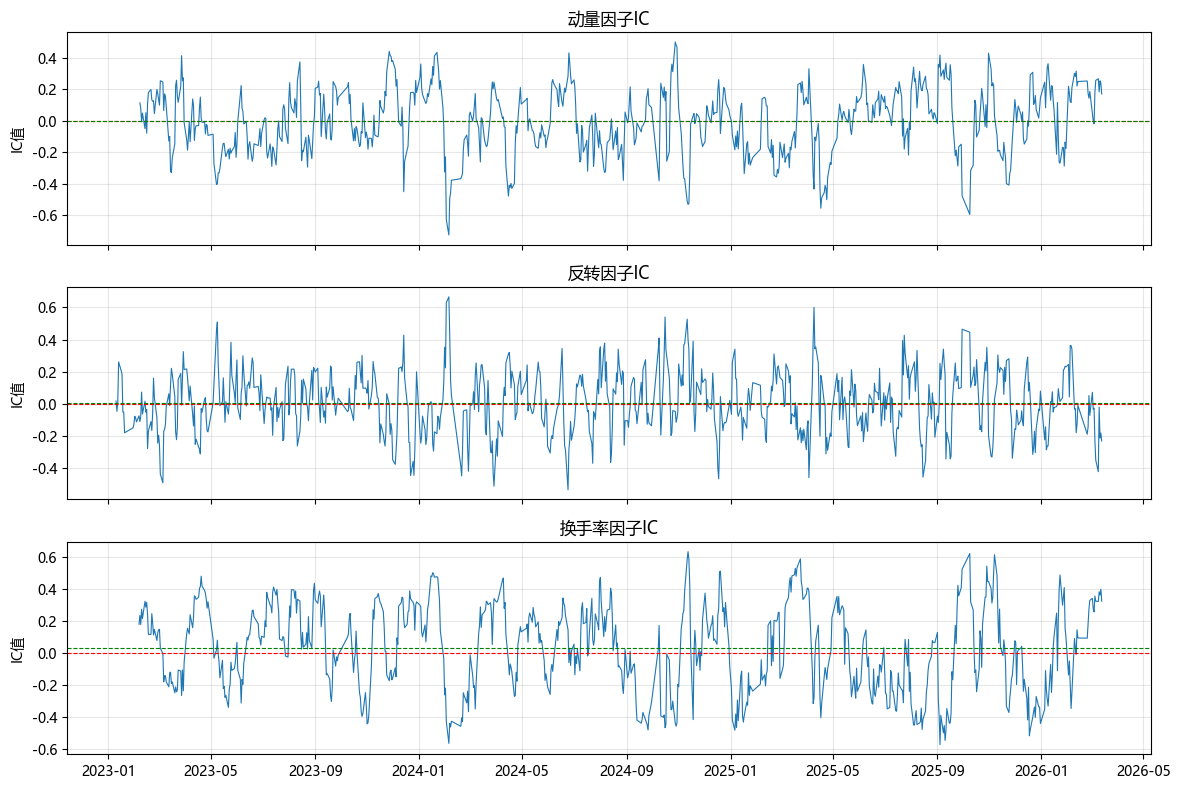

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, ic, title in zip(axes, 
                          [ic_series, ic_reversal, ic_turnover],
                          ["动量因子IC", "反转因子IC", "换手率因子IC"]):
    ax.plot(ic.index, ic, linewidth=0.8)
    ax.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
    ax.axhline(y=ic.mean(), color="green", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_ylabel("IC值")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 先对每个因子做标准化，统一量纲
def standardize(factor):
    return (factor - factor.mean()) / factor.std()

momentum_std = standardize(momentum_all)
reversal_std = standardize(reversal)
turnover_std = standardize(turnover_factor)

# 等权合成：三个因子各占1/3
combined_factor = (momentum_std + reversal_std + turnover_std) / 3

print(f"合成因子维度：{combined_factor.shape}")
print(combined_factor.iloc[20:23, :5])

合成因子维度：(781, 299)
              000001    000002    000063    000100    000157
日期                                                          
2023-02-07  0.756549  0.454133  0.471726  0.699198  0.772106
2023-02-08  0.446285  0.315202  0.527164  0.708944  0.800829
2023-02-09  0.312832  0.246067  0.411563  0.581610  0.603052
